# 12-3. GAN 입문

지금까지 이미지를 분류하는 모델을 배웠다.

이번 노트북에서는 이미지를 만들어내는 모델의 기본 구조를 본다.

GAN은 두 모델로 이루어진다.

```text
Generator: 가짜 이미지를 만든다.
Discriminator: 진짜와 가짜를 구분한다.
```

이 노트북은 CPU 환경을 고려해 긴 GAN 학습을 하지 않는다.
구조와 데이터 흐름을 이해하는 것이 목표다.


In [1]:

import numpy as np
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

# noise_dim은 Generator에 넣을 무작위 숫자 벡터의 길이다.
# 이 숫자 묶음이 이미지 생성의 출발 재료가 된다.
noise_dim = 100


## Generator 만들기

Generator는 noise를 받아 이미지 모양의 출력을 만든다.

여기서는 MNIST처럼 생긴 28x28 흑백 이미지를 목표 모양으로 둔다.

학습 전이므로 아직 의미 있는 이미지를 만들지는 못한다.


In [2]:

def make_generator():
    model = tf.keras.Sequential([
        # 길이 100짜리 noise 벡터를 입력으로 받는다.
        layers.Input(shape=(noise_dim,)),

        # Dense 층으로 7*7*64개의 숫자를 만든다.
        # 아직 이미지는 아니지만, 작은 특징 덩어리의 재료라고 생각하면 된다.
        layers.Dense(7 * 7 * 64, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 1차원 숫자 묶음을 7x7x64 모양으로 바꾼다.
        layers.Reshape((7, 7, 64)),

        # Conv2DTranspose는 작은 특징 덩어리를 더 큰 이미지 형태로 키운다.
        # 7x7 -> 14x14
        layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # 14x14 -> 28x28
        # 마지막 채널 수가 1이므로 흑백 이미지 한 장 모양이 된다.
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same", activation="tanh"),
    ])
    return model

generator = make_generator()
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3136)           │       313,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3136)           │        12,544 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 378,273 (1.44 MB)

 Trainable params: 371,937 (1.42 MB)

 Non-trainable params: 6,336 (24.75 KB)

Generator 출력 모양: (1, 28, 28, 1)


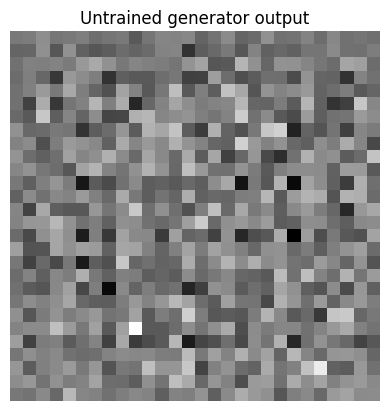

In [3]:

# noise 한 개를 만든다.
# 모양은 (샘플 수, noise_dim)이다.
noise = tf.random.normal([1, noise_dim])

# 아직 학습하지 않은 Generator에 noise를 넣어본다.
generated_image = generator(noise, training=False)

print("Generator 출력 모양:", generated_image.shape)

plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Untrained generator output")
plt.axis("off")
plt.show()


## Discriminator 만들기

Discriminator는 이미지를 보고 진짜인지 가짜인지 판단한다.

이 구조는 우리가 배운 CNN 분류 모델과 꽤 비슷하다.
다만 마지막 출력은 클래스 10개가 아니라 진짜/가짜 판단을 위한 점수 1개다.


In [4]:

def make_discriminator():
    model = tf.keras.Sequential([
        # 28x28 흑백 이미지를 입력으로 받는다.
        layers.Input(shape=(28, 28, 1)),

        # CNN처럼 이미지 특징을 찾는다.
        layers.Conv2D(32, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),

        # 최종 출력은 점수 1개다.
        # 이 값이 크면 진짜에 가깝다고 해석할 수 있다.
        layers.Dense(1),
    ])
    return model

discriminator = make_discriminator()
discriminator.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,233 (215.75 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:

# Generator가 만든 이미지를 Discriminator에 넣어본다.
# 아직 두 모델 모두 학습 전이므로 점수 자체에 큰 의미는 없다.
decision = discriminator(generated_image, training=False)
print("Discriminator 점수:", decision.numpy())


Discriminator 점수: [[0.01251404]]


## GAN의 loss 모양 보기

GAN에서는 Generator와 Discriminator가 서로 다른 목표를 가진다.

```text
Discriminator: 진짜는 진짜로, 가짜는 가짜로 맞히고 싶다.
Generator: 가짜를 진짜처럼 보이게 만들고 싶다.
```

그래서 loss도 두 종류로 나누어 생각한다.


In [6]:

# from_logits=True는 Discriminator의 마지막 출력에 sigmoid를 따로 붙이지 않았다는 뜻이다.
# BinaryCrossentropy는 진짜/가짜처럼 두 가지를 구분할 때 자주 쓰는 loss다.
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    # 진짜 이미지에 대해서는 1에 가깝게 예측하기를 바란다.
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    # 가짜 이미지에 대해서는 0에 가깝게 예측하기를 바란다.
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator는 Discriminator가 가짜 이미지를 진짜라고 믿게 만들고 싶어한다.
    # 그래서 fake_output이 1에 가까워지기를 바란다.
    return cross_entropy(tf.ones_like(fake_output), fake_output)


In [7]:

# loss 함수가 어떤 값을 반환하는지 작은 예시로 확인한다.
real_output_example = tf.constant([[1.5], [0.8]])   # 진짜 이미지에 대한 판별 점수 예시
fake_output_example = tf.constant([[-0.5], [0.2]])  # 가짜 이미지에 대한 판별 점수 예시

d_loss = discriminator_loss(real_output_example, fake_output_example)
g_loss = generator_loss(fake_output_example)

print("Discriminator loss 예시:", d_loss.numpy())
print("Generator loss 예시:", g_loss.numpy())


Discriminator loss 예시: 0.9223649
Generator loss 예시: 0.7861079


## 정리

이번 노트북에서는 GAN을 오래 학습하지 않았다.
대신 다음 구조를 확인했다.

```text
noise -> Generator -> fake image
fake image -> Discriminator -> real/fake score
```

GAN을 제대로 학습시키는 것은 더 어렵지만,
기본 구조는 이 두 모델의 경쟁으로 이해하면 된다.
